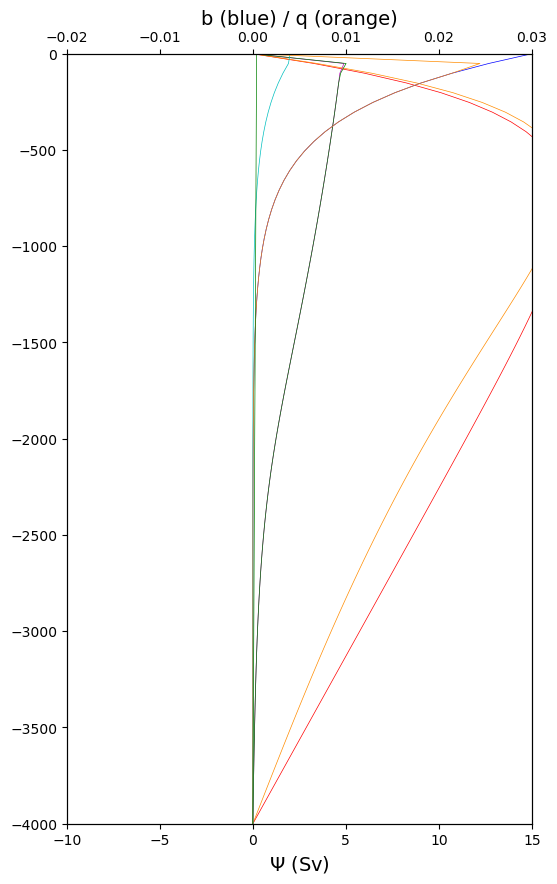

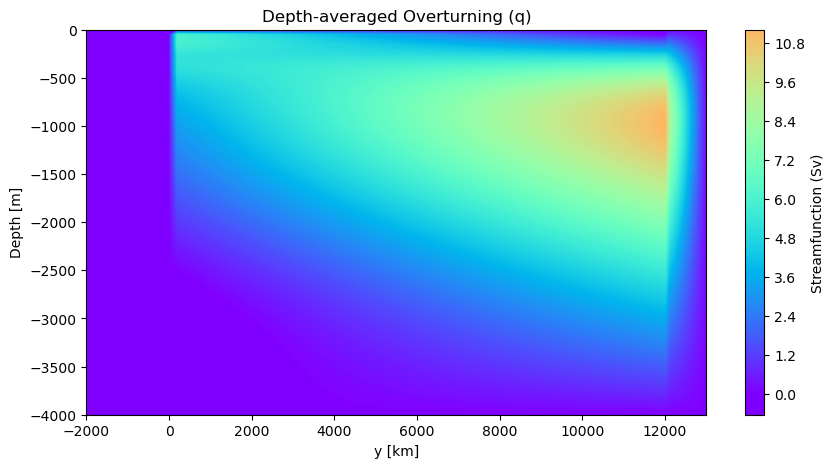

In [49]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

from pymoc.modules import Column
from pymoc.modules import Psi_Thermwind
from pymoc.modules import Psi_SO
from pymoc.plotting import Interpolate_channel

from pymoc.modules.Qolumn import Qolumn as Qolumn
from pymoc.modules.Qsi_thermwind import Qsi_Thermwind as Qsi_Thermwind
from pymoc.modules.Qsi_SO import Qsi_SO as Qsi_SO

bs = 0.03
bs_north = 0.004
bmin = 0.0

qs = 0.03
qs_north = 0.004
qmin = 0.0

l = 2.0e6
y = np.linspace(0, l, 40)
tau = 0.13
bs_SO = (bs - bmin) * (y / y[-1])**2 + bmin
qs_SO = (qs - qmin) * (y / y[-1])**2 + qmin
A_basin = 6e13
A_north = A_basin / 50

dt = 86400 * 30


MOC_up_iters = int(np.floor(2.0 * 360 * 86400 / dt))
plot_iters = int(np.ceil(300 * 360 * 86400 / dt))

total_iters_b = int(np.ceil(3500 * 360 * 86400 / dt))
total_iters_q = int(np.ceil(100 * 360 * 86400 / dt))

kappa = 3e-5
z = np.linspace(-4000, 0, 80)

def q_north_surface_decay(y_array, z_array, q_max=0.03):
    q_init = np.zeros((len(y_array), len(z_array)))
    y_mid = y_array[len(y_array)//2]  # midpoint of y
    for iy, yy in enumerate(y_array):
        surface_decay = max(0, 1 - (yy / y_mid))  # decays from 1 to 0
        q_init[iy, :] = q_max * surface_decay * np.exp(z_array / 300.0)
    return q_init


def b_basin(z_in):
    return bs * np.exp(z_in / 300.0)

def b_north(z_in):
    return bs_north * np.exp(z_in / 300.0)

def q_basin_init(z_in):
    return qs * np.exp(z_in / 300.0)

def q_north_init(z_in):
    return qs_north * np.exp(z_in / 300.0)

AMOC_b = Psi_Thermwind(z=z, b1=b_basin, b2=b_north, f=1e-4)
AMOC_b.solve()
Psi_iso_b, Psi_iso_n = AMOC_b.Psibz()

SO_b = Psi_SO(
    z=z, y=y, b=b_basin(z), bs=bs_SO, tau=tau,
    f=1e-4, L=5e6, KGM=1000., c=0.1, bvp_with_Ek=True
)
SO_b.solve()

basin_b = Column(z=z, kappa=kappa, Area=A_basin, b=b_basin, bs=bs, bbot=bmin)
north_b = Column(z=z, kappa=kappa, Area=A_north, b=b_north, bs=bs_north, bbot=bmin)

AMOC_q = Qsi_Thermwind(z=z, q1=q_basin_init, q2=q_north_init, f=1e-4)
AMOC_q.solve()
Psi_iso_qb, Psi_iso_qn = AMOC_q.Psiqz()

SO_q = Qsi_SO(
    z=z, y=y, q=q_basin_init(z), qs=qs_SO, tau=tau,
    f=1e-4, L=5e6, KGM=1000., c=0.1, bvp_with_Ek=True
)
SO_q.solve()

basin_q = Qolumn(z=z, kappa=kappa, Area=A_basin, q=q_basin_init)
north_q = Qolumn(z=z, kappa=kappa, Area=A_north, q=q_north_init)

fig = plt.figure(figsize=(6, 10))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()
plt.ylim((-4e3, 0))
ax1.set_xlim((-10, 15))
ax2.set_xlim((-0.02, 0.03))
ax1.set_xlabel('$\\Psi$ (Sv)', fontsize=14)
ax2.set_xlabel('b (blue) / q (orange)', fontsize=14)

surface_idx = -1

for ii in range(0, total_iters_b):

    wAb = (Psi_iso_b - SO_b.Psi) * 1e6
    wAN = -Psi_iso_n * 1e6

    basin_b.timestep(wA=wAb, dt=dt)
    north_b.timestep(wA=wAN, dt=dt, do_conv=True)

    if ii < total_iters_q:

        wAq_b = (Psi_iso_qb - SO_q.Psi) * 1e6
        wAq_n = -Psi_iso_qn * 1e6

        Area_b = basin_q.Area(basin_q.z)
        Area_n = north_q.Area(north_q.z)

        vdx_in_profile_b = (wAq_n - wAq_b) / Area_b
        vdx_in_profile_n = -vdx_in_profile_b

        basin_q.timestep(
            wA=wAq_b,
            dt=dt,
            vdx_in=vdx_in_profile_b,
            q_in=north_q.q
        )

        north_q.timestep(
            wA=wAq_n,
            dt=dt,
            do_conv=True,
            vdx_in=vdx_in_profile_n,
            q_in=basin_q.q
        )


    if ii % MOC_up_iters == 0:
        AMOC_b.update(b1=basin_b.b, b2=north_b.b)
        AMOC_b.solve()
        Psi_iso_b, Psi_iso_n = AMOC_b.Psibz()
        SO_b.update(b=basin_b.b)
        SO_b.solve()

        if ii < total_iters_q:
            AMOC_q.update(q1=basin_q.q, q2=north_q.q)
            AMOC_q.solve()
            Psi_iso_qb, Psi_iso_qn = AMOC_q.Psiqz()
            SO_q.update(q=basin_q.q)
            SO_q.solve()

    if ii % plot_iters == 0:
        ax1.plot(AMOC_b.Psi, AMOC_b.z, linewidth=0.5, color='r')
        ax1.plot(SO_b.Psi, SO_b.z, linewidth=0.5, color='m')
        ax2.plot(basin_b.b, basin_b.z, linewidth=0.5, color='b')
        ax2.plot(north_b.b, north_b.z, linewidth=0.5, color='c')

        if ii < total_iters_q:
            ax1.plot(AMOC_q.Psi, AMOC_q.z, linewidth=0.5, color='darkorange')
            ax1.plot(SO_q.Psi, SO_q.z, linewidth=0.5, color='green')
            ax2.plot(basin_q.q, basin_q.z, linewidth=0.5, color='darkorange')
            ax2.plot(north_q.q, north_q.z, linewidth=0.5, color='green')

        plt.pause(0.01)

ax1.plot(AMOC_b.Psi, AMOC_b.z, linewidth=2, color='r', label='AMOC (b)')
ax1.plot(SO_b.Psi, SO_b.z, linewidth=2, color='m', label='SO (b)')
ax1.plot(SO_b.Psi_Ek, SO_b.z, linewidth=1, color='m', linestyle='--', label='Ekman (b)')
ax1.plot(SO_b.Psi_GM, SO_b.z, linewidth=1, color='m', linestyle=':', label='GM (b)')

ax1.plot(AMOC_q.Psi, AMOC_q.z, linewidth=2, color='darkorange', label='AMOC (q)')
ax1.plot(SO_q.Psi, SO_q.z, linewidth=2, color='green', label='SO (q)')

ax2.plot(basin_b.b, basin_b.z, linewidth=2, color='b')
ax2.plot(north_b.b, north_b.z, linewidth=2, color='c')
ax2.plot(basin_q.q, basin_q.z, linewidth=2, color='darkorange')
ax2.plot(north_q.q, north_q.z, linewidth=2, color='green')
ax1.plot(0.0 * AMOC_b.z, AMOC_b.z, linewidth=0.5, color='k')
ax1.legend(loc='lower right', fontsize=8)

bint = Interpolate_channel(y=y, z=z, bs=bs_SO, bn=basin_b.b)
bsouth = bint.gridit()

ybasin = np.linspace(200., 12000., 60)
bbasin = np.tile(basin_b.b, (len(ybasin), 1))

ynorth = np.linspace(12100., 13000., 10)
bnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
    bnorth[:, iz] = interp1d(
        [11900., 12000., 12900., 13000.],
        [basin_b.b[iz], basin_b.b[iz], north_b.b[iz], north_b.b[iz]],
        kind='quadratic'
    )(ynorth)

ynew = np.concatenate(((y - l) / 1e3, ybasin, ynorth))
bnew = np.concatenate((bsouth, bbasin, bnorth))

psiarray_iso_b = np.zeros((len(ynew), len(z)))
psiarray_z_b   = np.zeros((len(ynew), len(z)))

for iy in range(1, len(y)):
    psiarray_iso_b[iy, :] = np.interp(bnew[iy, :], basin_b.b, SO_b.Psi)
    psiarray_z_b[iy, :]   = psiarray_iso_b[iy, :]
for iy in range(len(y), len(y) + len(ybasin)):
    psiarray_iso_b[iy, :] = (ynew[iy] * AMOC_b.Psibz()[0] + (10000. - ynew[iy]) * SO_b.Psi) / 10000.
    psiarray_z_b[iy, :]   = (ynew[iy] * AMOC_b.Psi + (10000. - ynew[iy]) * SO_b.Psi) / 10000.
for iy in range(len(y) + len(ybasin), len(ynew)):
    psiarray_iso_b[iy, :] = np.interp(bnew[iy, :], AMOC_b.bgrid, AMOC_b.Psib())
    psiarray_z_b[iy, :]   = ((13000. - ynew[iy]) * AMOC_b.Psi) / 1000.
psiarray_iso_b[-1, :] = 0.0

blevs = np.arange(0.001, 0.03, 0.002)
plevs = np.concatenate((np.arange(-15., -0.4, 0.5), np.arange(1., 16., 1.)))

# fig = plt.figure(figsize=(10, 5))
# ax = fig.add_subplot(111)
# CSb = ax.contour(ynew, z, bnew.T, levels=blevs, colors='k', linewidths=1.0, linestyles='solid')
# ax.clabel(CSb, fontsize=10)
# ax.contour(ynew, z, psiarray_iso_b.T, levels=plevs, colors='k', linewidths=0.5)
# CSf = ax.contourf(ynew, z, psiarray_iso_b.T, levels=plevs, cmap=plt.cm.bwr, vmin=-15, vmax=15)
# cbar = fig.colorbar(CSf, ax=ax)
# cbar.set_label('Streamfunction (Sv)')
# ax.set_xlabel('y [km]')
# ax.set_ylabel('Depth [m]')
# ax.set_title('Isopycnal Overturning (buoyancy)')

# fig = plt.figure(figsize=(10, 5))
# ax = fig.add_subplot(111)
# CSb = ax.contour(ynew, z, bnew.T, levels=blevs, colors='k', linewidths=1.0, linestyles='solid')
# ax.clabel(CSb, fontsize=10)
# ax.contour(ynew, z, psiarray_z_b.T, levels=plevs, colors='k', linewidths=0.5)
# CSf = ax.contourf(ynew, z, psiarray_z_b.T, levels=plevs, cmap=plt.cm.bwr, vmin=-15, vmax=15)
# cbar = fig.colorbar(CSf, ax=ax)
# cbar.set_label('Streamfunction (Sv)')
# ax.set_xlabel('y [km]')
# ax.set_ylabel('Depth [m]')
# ax.set_title('Depth-averaged Overturning (buoyancy)')

qint = Interpolate_channel(y=y, z=z, bs=qs_SO, bn=basin_b.b)
qsouth = qint.gridit()

ybasin = np.linspace(200., 12000., 60)
qbasin = np.tile(basin_q.q, (len(ybasin), 1))

ynorth = np.linspace(12100., 13000., 10)
qnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
    qnorth[:, iz] = interp1d(
        [11900., 12000., 12900., 13000.],
        [basin_q.q[iz], basin_q.q[iz], north_q.q[iz], north_q.q[iz]],
        kind='quadratic'
    )(ynorth)

ynew = np.concatenate(((y - l) / 1e3, ybasin, ynorth))
qnew = np.concatenate((qsouth, qbasin, qnorth))

psiarray_iso_q = np.zeros((len(ynew), len(z)))
psiarray_z_q   = np.zeros((len(ynew), len(z)))
for iy in range(1, len(y)):
    psiarray_iso_q[iy, :] = np.interp(qnew[iy, :], basin_q.q, SO_q.Psi)
    psiarray_z_q[iy, :]   = psiarray_iso_q[iy, :]
for iy in range(len(y), len(y) + len(ybasin)):
    psiarray_iso_q[iy, :] = (ynew[iy] * AMOC_q.Psiqz()[0] + (10000. - ynew[iy]) * SO_q.Psi) / 10000.
    psiarray_z_q[iy, :]   = (ynew[iy] * AMOC_q.Psi + (10000. - ynew[iy]) * SO_q.Psi) / 10000.
for iy in range(len(y) + len(ybasin), len(ynew)):
    psiarray_iso_q[iy, :] = np.interp(qnew[iy, :], AMOC_q.qgrid, AMOC_q.Psiq())
    psiarray_z_q[iy, :]   = ((13000. - ynew[iy]) * AMOC_q.Psi) / 1000.
psiarray_iso_q[-1, :] = 0.0

qlevs = np.linspace(0, np.nanmax(qnew), 12)

# fig = plt.figure(figsize=(10, 5))
# ax = fig.add_subplot(111)
# CSq = ax.contour(ynew, z, qnew.T, levels=qlevs, colors='k', linewidths=1.0, linestyles='solid')
# ax.clabel(CSq, fontsize=10)
# ax.contour(ynew, z, psiarray_iso_q.T, levels=plevs, colors='k', linewidths=0.5)
# CSf = ax.contourf(ynew, z, psiarray_iso_q.T, levels=plevs, cmap=plt.cm.rainbow, vmin=-15, vmax=15)
# cbar = fig.colorbar(CSf, ax=ax)
# cbar.set_label('Streamfunction (Sv)')
# ax.set_xlabel('y [km]')
# ax.set_ylabel('Depth [m]')
# ax.set_title('Isotracer Overturning (q)')

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
# CSq = ax.contour(ynew, z, qnew.T, levels=qlevs, colors='k', linewidths=1.0, linestyles='solid')
ax.clabel(CSq, fontsize=10)
# ax.contour(ynew, z, psiarray_z_q.T, levels=plevs, colors='k', linewidths=0.5)
CSf = ax.contourf(ynew, z, psiarray_z_q.T, levels=1000, cmap=plt.cm.rainbow, vmin=0, vmax=15)
cbar = fig.colorbar(CSf, ax=ax)
cbar.set_label('Streamfunction (Sv)')
ax.set_xlabel('y [km]')
ax.set_ylabel('Depth [m]')
ax.set_title('Depth-averaged Overturning (q)')

plt.show()


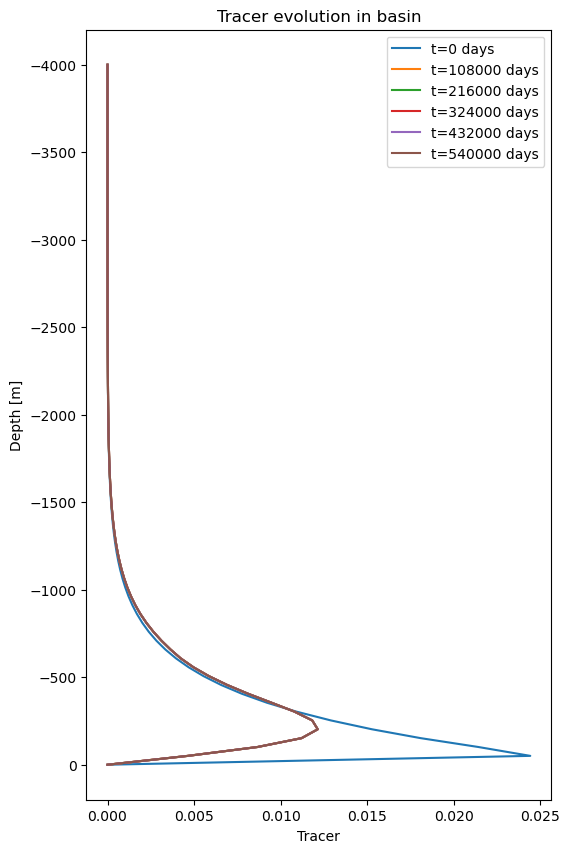

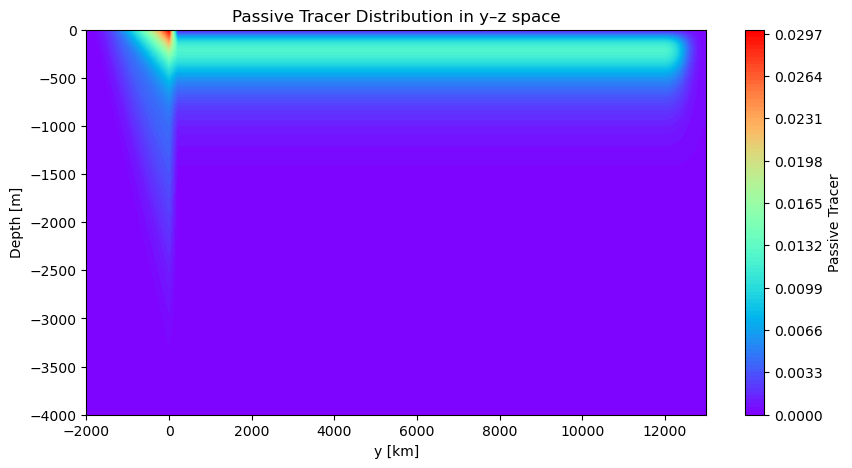

In [27]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

from pymoc.modules import Column
from pymoc.modules import Psi_Thermwind
from pymoc.modules import Psi_SO
from pymoc.modules.Qolumn import Qolumn as Qolumn
from pymoc.modules.Qsi_thermwind import Qsi_Thermwind as Qsi_Thermwind
from pymoc.modules.Qsi_SO import Qsi_SO as Qsi_SO
from pymoc.plotting import Interpolate_channel

# Model parameters
bs = 0.03
bs_north = 0.004
bmin = 0.0
qs = 0.03
qs_north = 0.004
qmin = 0.0
l = 2.0e6
y = np.linspace(0, l, 40)
tau = 0.13
bs_SO = (bs - bmin) * (y / y[-1])**2 + bmin
qs_SO = (qs - qmin) * (y / y[-1])**2 + qmin
A_basin = 6e13
A_north = A_basin / 50
dt = 86400 * 30

MOC_up_iters = int(np.floor(2.0 * 360 * 86400 / dt))
plot_iters = int(np.ceil(300 * 360 * 86400 / dt))

total_iters_b = int(np.ceil(3500 * 360 * 86400 / dt))
total_iters_q = int(np.ceil(10 * 360 * 86400 / dt))
kappa = 3e-5
z = np.linspace(-4000, 0, 80)

# Buoyancy and tracer profiles
def b_basin(z_in): return bs * np.exp(z_in / 300.0)
def b_north(z_in): return bs_north * np.exp(z_in / 300.0)
def q_basin_init(z_in): return qs * np.exp(z_in / 300.0)
def q_north_init(z_in): return qs_north * np.exp(z_in / 300.0)

# AMOC and Southern Ocean setups
AMOC_b = Psi_Thermwind(z=z, b1=b_basin, b2=b_north, f=1e-4)
AMOC_b.solve()
Psi_iso_b, Psi_iso_n = AMOC_b.Psibz()

SO_b = Psi_SO(z=z, y=y, b=b_basin(z), bs=bs_SO, tau=tau,
              f=1e-4, L=5e6, KGM=1000., c=0.1, bvp_with_Ek=True)
SO_b.solve()

basin_b = Column(z=z, kappa=kappa, Area=A_basin, b=b_basin, bs=bs, bbot=bmin)
north_b = Column(z=z, kappa=kappa, Area=A_north, b=b_north, bs=bs_north, bbot=bmin)

AMOC_q = Qsi_Thermwind(z=z, q1=q_basin_init, q2=q_north_init, f=1e-4)
AMOC_q.solve()
Psi_iso_qb, Psi_iso_qn = AMOC_q.Psiqz()

SO_q = Qsi_SO(z=z, y=y, q=q_basin_init(z), qs=qs_SO, tau=tau,
              f=1e-4, L=5e6, KGM=1000., c=0.1, bvp_with_Ek=True)
SO_q.solve()

basin_q = Qolumn(z=z, kappa=kappa, Area=A_basin, q=q_basin_init)
north_q = Qolumn(z=z, kappa=kappa, Area=A_north, q=q_north_init)

# Define passive tracer injection
def inject_tracer(q_array, z, amount, z_target=-10):
    idx = np.argmin(np.abs(z - z_target))
    q_array[idx] += amount
    return q_array

tracer_injection_time = 200
tracer_amount = 0.01
tracer_depth = -50

# Store snapshots for plotting
tracer_history = []

# Main model loop
for ii in range(total_iters_b):

    wAb = (Psi_iso_b - SO_b.Psi) * 1e6
    wAN = -Psi_iso_n * 1e6

    basin_b.timestep(wA=wAb, dt=dt)
    north_b.timestep(wA=wAN, dt=dt, do_conv=True)

    if ii < total_iters_q:
        vdx_in_profile_b = np.zeros_like(basin_q.q)
        vdx_in_profile_n = np.zeros_like(north_q.q)

        basin_q.timestep(
            wA=wAb,
            dt=dt,
            vdx_in=vdx_in_profile_b,
            q_in=north_q.q
        )
        north_q.timestep(
            wA=wAN,
            dt=dt,
            do_conv=True,
            vdx_in=vdx_in_profile_n,
            q_in=basin_q.q
        )

        # inject tracer
        if ii == tracer_injection_time:
            north_q.q = inject_tracer(basin_q.q, z, tracer_amount, tracer_depth)

    if ii % plot_iters == 0:
        tracer_history.append(basin_q.q.copy())

    # Update AMOC and SO for buoyancy only (q is passive now)
    if ii % MOC_up_iters == 0:
        AMOC_b.update(b1=basin_b.b, b2=north_b.b)
        AMOC_b.solve()
        Psi_iso_b, Psi_iso_n = AMOC_b.Psibz()
        SO_b.update(b=basin_b.b)
        SO_b.solve()

tracer_history = np.array(tracer_history)

# 1D profile plot
plt.figure(figsize=(6, 10))
for i, q_snap in enumerate(tracer_history[::len(tracer_history)//5]):
    plt.plot(q_snap, z, label=f't={i*plot_iters*dt/86400:.0f} days')
plt.gca().invert_yaxis()
plt.xlabel('Tracer')
plt.ylabel('Depth [m]')
plt.title('Tracer evolution in basin')
plt.legend()
plt.show()

# 2D y–z plot
qint = Interpolate_channel(y=y, z=z, bs=qs_SO, bn=basin_b.b)
qsouth = qint.gridit()

ybasin = np.linspace(200., 12000., 60)
qbasin = np.tile(basin_q.q, (len(ybasin), 1))

ynorth = np.linspace(12100., 13000., 10)
qnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
    qnorth[:, iz] = interp1d(
        [11900., 12000., 12900., 13000.],
        [basin_q.q[iz], basin_q.q[iz], north_q.q[iz], north_q.q[iz]],
        kind='quadratic'
    )(ynorth)

ynew = np.concatenate(((y - l) / 1e3, ybasin, ynorth))
qnew = np.concatenate((qsouth, qbasin, qnorth))

# 2D plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
CSf = ax.contourf(ynew, z, qnew.T, levels=100, cmap=plt.cm.rainbow)
cbar = fig.colorbar(CSf, ax=ax)
cbar.set_label('Passive Tracer')
ax.set_xlabel('y [km]')
ax.set_ylabel('Depth [m]')
ax.set_title('Passive Tracer Distribution in y–z space')
plt.show()


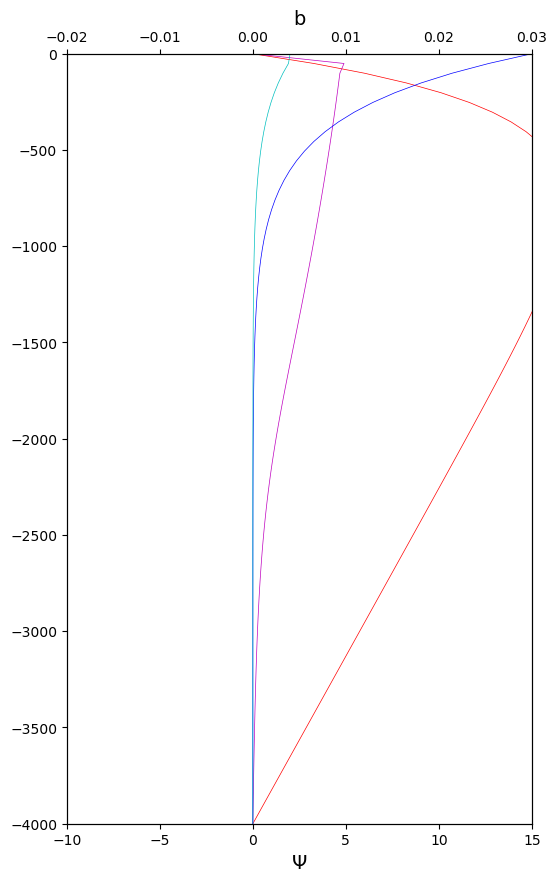

Tracer injected into north column at iteration 1000


Text(0.5, 1.0, 'Depth-averaged Overturning')

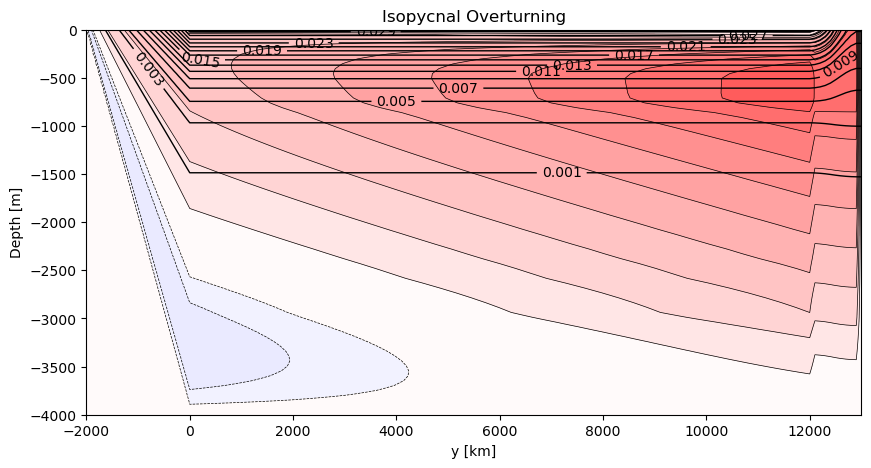

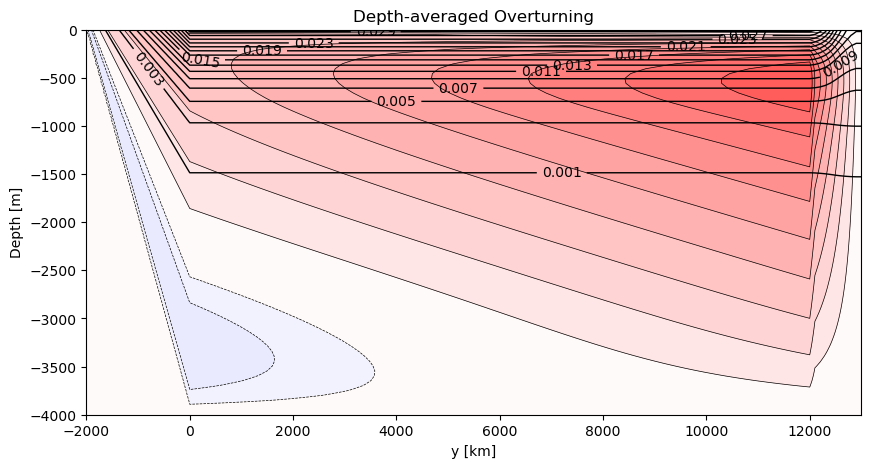

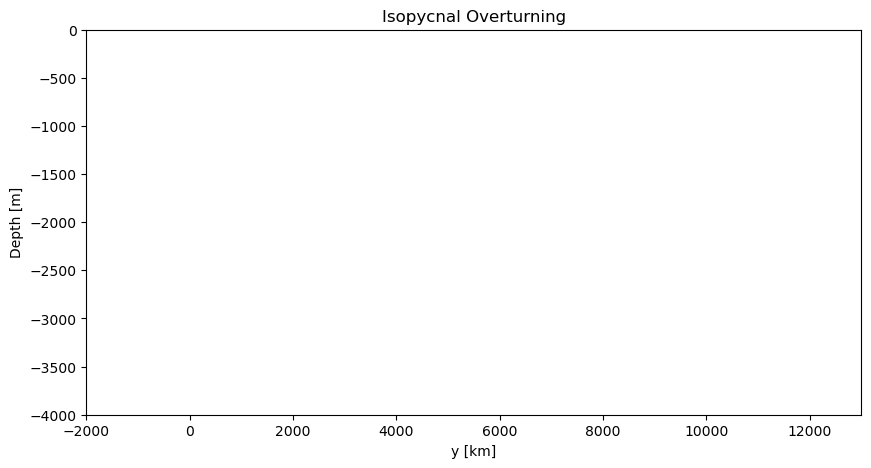

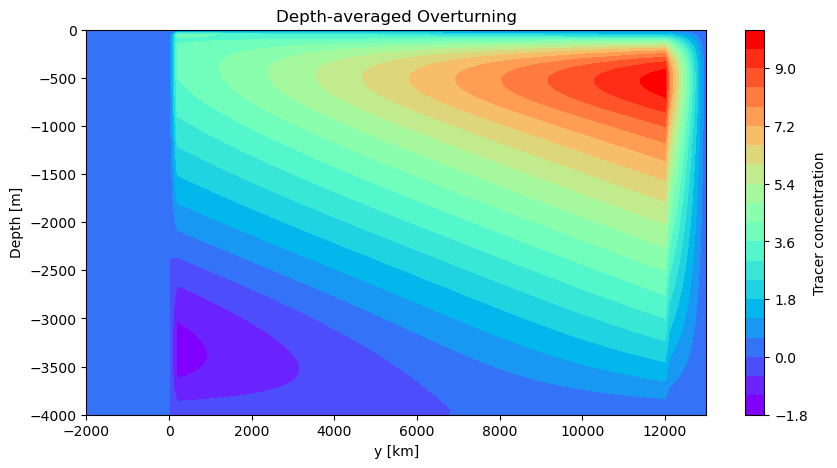

In [12]:
'''
This script shows an example of a "two column" model for the 
overturning circulation in a basin connected to a channel in the south.
The first column represents the basin, while the second column represents
the northern sinking region. The overtunning circulation is computed at
the northern end of the basin (at the interface to the northern sinking region)
and at the southern end of the basin (at the interface to the channel).
The parameters chosen here follow more or less the "control" experiment of Nikurashin
and Vallis (2012, JPO).
'''
from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

# boundary conditions:
bs = 0.03
bs_north = 0.004
bmin = 0.0

# S.O. surface boundary conditions and grid:
l = 2.e6
y = np.asarray(np.linspace(0, l, 40))
#Although the model can emulate the effect of a meridionally varying wind-stress,
# that feature is in "beta" and we are here for simplicity using a constant
# wind-stress (approximately the average over the channel in NV12):
tau = 0.13
# from what I can infer, NV12 use an approximately quadratic surface temperature
# profile in the channel for their SAMBUCA simulations:
bs_SO = (bs-bmin) * (y / y[-1])**2 + bmin
ts_SO = np.zeros(np.shape(bs_SO))
A_basin = 6e13    #area of the basin
A_north = A_basin / 50.    #area of northern sinking region

# time-stepping parameters:
dt = 86400 * 30    # time-step for vert. adv. diff. calc.
MOC_up_iters = int(
    np.floor(2. * 360 * 86400 / dt)
)    # multiplier for MOC time-step (MOC is updated every MOC_up_iters time steps)
plot_iters = int(
    np.ceil(300 * 360 * 86400 / dt)
)    # plotting frequency (in iterations)
total_iters = int(
    np.ceil(3000 * 360 * 86400 / dt)
)    # total number of timesteps

kappa = 3e-5

# create vertical grid:
z = np.asarray(np.linspace(-4000, 0, 80))


# Initial conditions for buoyancy profile in the basin
def b_basin(z):
  return bs * np.exp(z / 300.)
def b_north(z):
  return bs_north * np.exp(z / 300.)

def t_basin(z):
    return np.zeros(np.shape(b_basin(z)))

def t_north(z):
    return np.zeros(np.shape(b_north(z)))


# create N.A. overturning model instance
AMOC = Psi_Thermwind(z=z, b1=b_basin, b2=b_north, t1 = t_basin, t2 = t_north, f=1e-4)
# and solve for initial overturning streamfunction:
AMOC.solve()
# evaluate overturning in isopycnal space:
[Psi_iso_b, Psi_iso_n] = AMOC.Psibz()

# evaluate overutning in tracer space
[Psi_iso_b_t, Psi_iso_n_t] = AMOC.Psitz()


# create S.O. overturning model instance
SO = Psi_SO(
    z=z,
    y=y,
    b=b_basin(z),
    bs=bs_SO,
    tracer = t_basin(z),
    ts = 0,
    tau=tau,
    f=1e-4,
    L=5e6,
    KGM=1000.,
    c=0.1,
    bvp_with_Ek=True
)
SO.solve()

# create adv-diff column model instance for basin
basin = Column(z=z, kappa=kappa, Area=A_basin, b=b_basin, bs=bs, bbot=bmin)
# create adv-diff column model instance for basin
north = Column(z=z, kappa=kappa, Area=A_north, b=b_north, bs=bs_north, bbot=bmin)

# Create figure:
fig = plt.figure(figsize=(6, 10))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()
plt.ylim((-4e3, 0))
ax1.set_xlim((-10, 15))
ax2.set_xlim((-0.02, 0.03))
ax1.set_xlabel('$\Psi$', fontsize=14)
ax2.set_xlabel('b', fontsize=14)

# Main time-stepping loop:
for ii in range(total_iters):
    # Overturning tendencies
    wAb = (Psi_iso_b - SO.Psi) * 1e6
    wAN = -Psi_iso_n * 1e6

    if ii < 1000:
        basin.timestep(wA=wAb, dt=dt)
        north.timestep(wA=wAN, dt=dt, do_conv=True)
    else:

        if ii == 1000:
            north.add_tracer(amount=1000, as_concentration=False)
            print("Tracer injected into north column at iteration", ii)

        Q_basin = (SO.Psi - Psi_iso_b) * 1e6 
        Q_north = Psi_iso_n * 1e6 
        dz = np.diff(z); dz = np.append(dz, dz[-1])  # layer thicknesses
        vdx_in_basin = Q_basin / dz
        vdx_in_north = Q_north / dz
        b_in_basin = basin.b.copy()        # or a prescribed channel buoyancy profile
        tracer_in_basin = np.zeros_like(basin.b)  # channel tracer = 0
        b_in_north = basin.b.copy()
        tracer_in_north = basin.tracer.copy()


        basin.timestep(
            wA=wAb, dt=dt,
            vdx_in=vdx_in_basin,
            b_in=b_in_basin,
            tracer_in=tracer_in_basin
        )
        
        north.timestep(
            wA=wAN, dt=dt, do_conv=True,
            vdx_in=vdx_in_north,
            b_in=b_in_north,
            tracer_in=tracer_in_north
        )


    if ii % MOC_up_iters == 0:
        AMOC.update(b1=basin.b, b2=north.b)
        AMOC.solve()
        Psi_iso_b, Psi_iso_n = AMOC.Psibz()
        # Psi_iso_b_t, Psi_iso_n_t = AMOC.Psitz()

        SO.update(b=basin.b)
        SO.solve()

    if ii % plot_iters == 0:
        ax1.plot(AMOC.Psi, AMOC.z, linewidth=0.5, color='r')
        ax1.plot(SO.Psi, SO.z, linewidth=0.5, color='m')
        ax2.plot(basin.b, basin.z, linewidth=0.5, color='b')
        ax2.plot(north.b, north.z, linewidth=0.5, color='c')
        plt.pause(0.01)


# # Plot final results over time-iteration plot:
# ax1.plot(AMOC.Psi, AMOC.z, linewidth=2, color='r')
# ax1.plot(SO.Psi, SO.z, linewidth=2, color='m')
# ax1.plot(SO.Psi_Ek, SO.z, linewidth=1, color='m', linestyle='--')
# ax1.plot(SO.Psi_GM, SO.z, linewidth=1, color='m', linestyle=':')
# ax2.plot(basin.b, basin.z, linewidth=2, color='b')
# ax2.plot(north.b, basin.z, linewidth=2, color='c')
# ax1.plot(0. * AMOC.z, AMOC.z, linewidth=0.5, color='k')


#==============================================================================
# Everything below is just to make fancy 2D plots:
# This is mostly an exercise in interpolation, but useful to visualize solutions

# first interpolate buoyancy in channel along constant-slope isopycnals:
bint = Interpolate_channel(y=y, z=z, bs=bs_SO, bn=basin.b)
bsouth = bint.gridit()
# buoyancy in the basin is all the same:
ybasin = np.linspace(200., 12000., 60)
bbasin = np.tile(basin.b, (len(ybasin), 1))
# finally, interpolate buoyancy in the north:
ynorth = np.linspace(12100., 13000., 10)
bnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
  bnorth[:, iz] = interp1d([11900., 12000., 12900., 13000.], [
      basin.b[iz], basin.b[iz], north.b[iz], north.b[iz]
  ],
                           kind='quadratic')(ynorth)
# now stick it all together:
ynew = np.concatenate(((y-l) / 1e3, ybasin, ynorth))
bnew = np.concatenate((bsouth, bbasin, bnorth))

# Evaluate isopycnal overturning streamfunction at all latitudes:
psiarray_iso = np.zeros((len(ynew), len(z)))
psiarray_z = np.zeros((len(ynew), len(z)))
for iy in range(1, len(y)):
  # in the channel, interpolate SO.Psi onto local isopycnal depth:
  psiarray_iso[iy, :] = np.interp(bnew[iy, :], basin.b, SO.Psi)
  psiarray_z[iy, :] = psiarray_iso[iy, :]
for iy in range(len(y), len(y) + len(ybasin)):
  # in the basin, linearly interpolate between Psi_SO and Psi_AMOC:
  psiarray_iso[iy, :] = (
      ynew[iy] * AMOC.Psibz()[0] + (10000. - ynew[iy]) * SO.Psi
  ) / 10000.
  psiarray_z[iy, :
             ] = (ynew[iy] * AMOC.Psi + (10000. - ynew[iy]) * SO.Psi) / 10000.
for iy in range(len(y) + len(ybasin), len(ynew)):
  # in the north, interpolate AMOC.psib to local isopycnal depth:
  psiarray_iso[iy, :] = np.interp(bnew[iy, :], AMOC.bgrid, AMOC.Psib())
  psiarray_z[iy, :] = ((13000. - ynew[iy]) * AMOC.Psi) / 1000.
psiarray_iso[-1, :] = 0.

blevs = np.arange(0.001, 0.03, 0.002)
# Notice that the contour level for Psi is 0.5 SV for negative values
# and 1 SV for positive values. This appers to be what was used in NV2012.
plevs = np.concatenate((np.arange(-15., -0.4, 0.5), np.arange(1., 16., 1.)))

# plot isopycnal overturning:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
CS = ax1.contour(
    ynew,
    z,
    bnew.transpose(),
    levels=blevs,
    colors='k',
    linewidths=1.0,
    linestyles='solid'
)
ax1.clabel(CS, fontsize=10)
ax1.contour(
    ynew,
    z,
    psiarray_iso.transpose(),
    levels=plevs,
    colors='k',
    linewidths=0.5
)
CS = ax1.contourf(
    ynew,
    z,
    psiarray_iso.transpose(),
    levels=plevs,
    cmap=plt.cm.bwr,
    vmin=-15,
    vmax=15
)
#fig.colorbar(CS, ticks=plevs[0::2], orientation='vertical')
ax1.set_xlabel('y [km]')
ax1.set_ylabel('Depth [m]')
ax1.set_title('Isopycnal Overturning')

# plot z-coord. overturning:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
CS = ax1.contour(
    ynew,
    z,
    bnew.transpose(),
    levels=blevs,
    colors='k',
    linewidths=1.0,
    linestyles='solid'
)
ax1.clabel(CS, fontsize=10)
ax1.contour(
    ynew, z, psiarray_z.transpose(), levels=plevs, colors='k', linewidths=0.5
)
CS = ax1.contourf(
    ynew,
    z,
    psiarray_z.transpose(),
    levels=plevs,
    cmap=plt.cm.bwr,
    vmin=-15,
    vmax=15
)
#fig.colorbar(CS, ticks=plevs[0::2], orientation='vertical')
ax1.set_xlabel('y [km]')
ax1.set_ylabel('Depth [m]')
ax1.set_title('Depth-averaged Overturning')



bs = 1.0 * np.zeros(np.shape(bs_SO))
bn = 1.0 * basin.tracer.copy()

if bs[0] > bs[1]:
    bs[0] = bs[1]

if bs[0] <= bn[0]:
    bn[0] = bs[0] - 1e-12

tint = Interpolate_channel(y=y, z=z, bs=bs, bn=bn)
tsouth = tint.gridit()
# buoyancy in the basin is all the same:
ybasin = np.linspace(200., 12000., 60)
tbasin = np.tile(basin.tracer, (len(ybasin), 1))
# finally, interpolate buoyancy in the north:
ynorth = np.linspace(12100., 13000., 10)
tnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
  tnorth[:, iz] = interp1d([11900., 12000., 12900., 13000.], [
      basin.tracer[iz], basin.tracer[iz], north.tracer[iz], north.tracer[iz]
  ],
                           kind='quadratic')(ynorth)
# now stick it all together:
ynew = np.concatenate(((y-l) / 1e3, ybasin, ynorth))
tnew = np.concatenate((tsouth, tbasin, tnorth))

bs = 0
# Evaluate isopycnal overturning streamfunction at all latitudes:
psiarray_iso = np.zeros((len(ynew), len(z)))
psiarray_z = np.zeros((len(ynew), len(z)))
for iy in range(1, len(y)):
  # in the channel, interpolate SO.Psi onto local isopycnal depth:
  psiarray_iso[iy, :] = np.interp(tnew[iy, :], basin.tracer, SO.Psi)
  psiarray_z[iy, :] = psiarray_iso[iy, :]
for iy in range(len(y), len(y) + len(ybasin)):
  # in the basin, linearly interpolate between Psi_SO and Psi_AMOC:
  psiarray_iso[iy, :] = (
      ynew[iy] * AMOC.Psitz()[0] + (10000. - ynew[iy]) * SO.Psi
  ) / 10000.
  psiarray_z[iy, :
             ] = (ynew[iy] * AMOC.Psi + (10000. - ynew[iy]) * SO.Psi) / 10000.
for iy in range(len(y) + len(ybasin), len(ynew)):
  # in the north, interpolate AMOC.psib to local isopycnal depth:
  psiarray_iso[iy, :] = np.interp(tnew[iy, :], AMOC.tgrid, AMOC.Psit())
  psiarray_z[iy, :] = ((13000. - ynew[iy]) * AMOC.Psi) / 1000.
psiarray_iso[-1, :] = 0.

tlevs = np.arange(0.001, 0.03, 0.002)
# Notice that the contour level for Psi is 0.5 SV for negative values
# and 1 SV for positive values. This appers to be what was used in NV2012.
plevs = np.concatenate((np.arange(-15., -0.4, 0.5), np.arange(1., 16., 1.)))


# plot isopycnal overturning:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
CS = ax1.contour(
    ynew,
    z,
    tnew.transpose(),
    levels=tlevs,
    colors='k',
    linewidths=1.0,
    linestyles='solid'
)
ax1.clabel(CS, fontsize=10)
ax1.contour(
    ynew,
    z,
    psiarray_iso.transpose(),
    levels=plevs,
    colors='k',
    linewidths=0.5
)
CS = ax1.contourf(
    ynew,
    z,
    0.1*psiarray_iso.transpose(),
    levels=plevs,
    cmap=plt.cm.plasma,
    vmin=0,
    vmax=psiarray_iso.max()
)
#fig.colorbar(CS, ticks=plevs[0::2], orientation='vertical')
ax1.set_xlabel('y [km]')
ax1.set_ylabel('Depth [m]')
ax1.set_title('Isopycnal Overturning')

# plot z-coord. overturning:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)



CS = ax1.contourf(
    ynew,
    z,
    psiarray_z.transpose(),
    levels=20,
    cmap=plt.cm.rainbow,
    vmin=psiarray_z.min(),
    vmax=psiarray_z.max()
)



fig.colorbar(CS, orientation='vertical', label='Tracer concentration')
ax1.set_xlabel('y [km]')
ax1.set_ylabel('Depth [m]')
ax1.set_title('Depth-averaged Overturning')

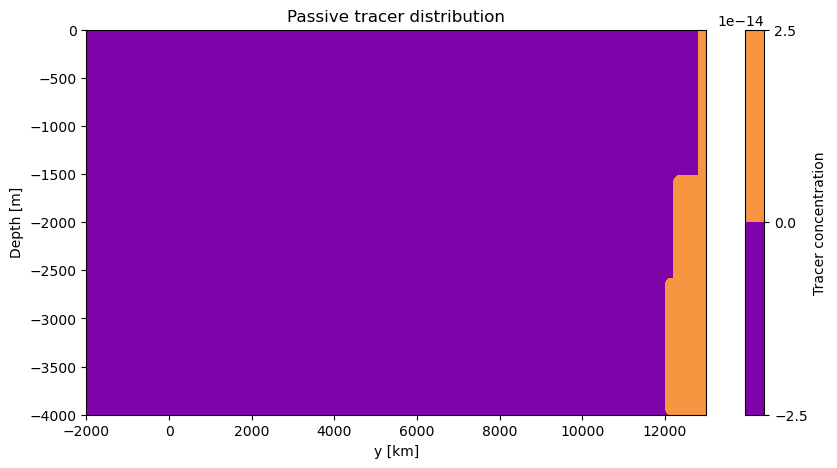

In [11]:
# Build tracer field across channel, basin, north
tsouth_tracer = np.zeros((len(y), len(z)))  # channel tracer (if none injected)
ybasin = np.linspace(200., 12000., 60)
tbasin_tracer = np.tile(basin.tracer, (len(ybasin), 1))

ynorth = np.linspace(12100., 13000., 10)
tnorth_tracer = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
    tnorth_tracer[:, iz] = interp1d(
        [11900., 12000., 12900., 13000.],
        [basin.tracer[iz], basin.tracer[iz], north.tracer[iz], north.tracer[iz]],
        kind="quadratic"
    )(ynorth)

ynew = np.concatenate(((y - l) / 1e3, ybasin, ynorth))
tracer_field = np.concatenate((tsouth_tracer, tbasin_tracer, tnorth_tracer))

# Plot tracer distribution
fig, ax = plt.subplots(figsize=(10, 5))
tmin, tmax = tracer_field.min(), tracer_field.max()
CS = ax.contourf(
    ynew, z, tracer_field.T,
    cmap=plt.cm.plasma, 
)
fig.colorbar(CS, orientation="vertical", label="Tracer concentration")
ax.set_xlabel("y [km]")
ax.set_ylabel("Depth [m]")
ax.set_title("Passive tracer distribution")
plt.show()


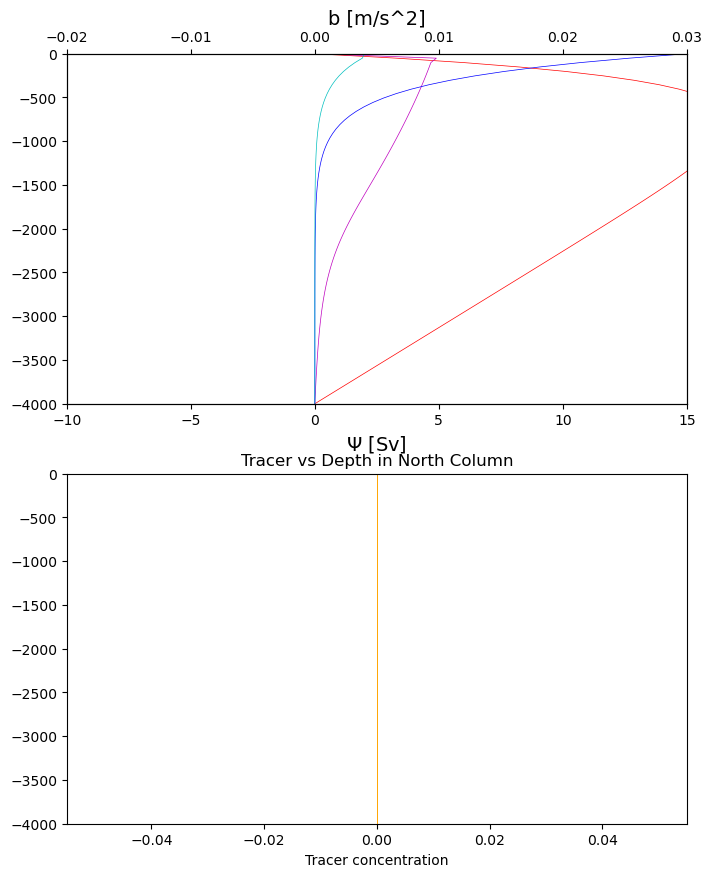

AttributeError: 'Interpolate_channel' object has no attribute 'set_tracer'

In [20]:
"""
Two-column AMOC with tracer: buoyancy-driven overturning in a basin connected to a Southern Ocean channel,
plus a passive tracer that advects, diffuses, convects, and exchanges horizontally between columns.

Tracer is injected at the northern surface after spin-up and propagated for 500 years. 
"""
from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d


bs = 0.03
bs_north = 0.004
bmin = 0.0

# S.O. surface boundary conditions and grid
l = 2.e6
y = np.asarray(np.linspace(0, l, 40))
tau = 0.13
bs_SO = (bs - bmin) * (y / y[-1])**2 + bmin

A_basin = 6e13          # area of the basin
A_north = A_basin / 50. # area of northern sinking region


dt = 86400 * 30    # 30-day time step
MOC_up_iters = int(np.floor(2. * 360 * 86400 / dt))       # update overturning every ~2 months
plot_iters = int(np.ceil(300 * 360 * 86400 / dt))         # quick-look plot frequency (~300 days)
spin_years = 3500
post_years = 10 # tracer propagation after injection
total_iters = int(np.ceil((spin_years + post_years) * 360 * 86400 / dt))
injection_iter = int(np.ceil(spin_years * 360 * 86400 / dt))
kappa = 3e-5       # diapycnal diffusivity (m^2/s)


z = np.asarray(np.linspace(-4000, 0, 80))


def b_basin(z):
    return bs * np.exp(z / 300.)

def b_north(z):
    return bs_north * np.exp(z / 300.)


basin = Column(z=z, kappa=kappa, Area=A_basin, b=b_basin, bs=bs, bbot=bmin)
north = Column(z=z, kappa=kappa, Area=A_north, b=b_north, bs=bs_north, bbot=bmin)

# Initialize tracer (zero initially)
basin.add_tracer(0.0)
north.add_tracer(0.0)



AMOC = Psi_Thermwind(z=z, b1=b_basin, b2=b_north, f=1e-4, t1 = 0.0001* np.ones(np.shape(b_basin)), t2 = 0.0001* np.ones(np.shape(b_north)))
AMOC.solve()
Psi_iso_b, Psi_iso_n = AMOC.Psibz()

SO = Psi_SO(
    z=z, y=y, b=b_basin(z), bs=bs_SO, tau=tau, f=1e-4,
    L=5e6, KGM=1000., c=0.1, bvp_with_Ek=True
)
SO.solve()

t_basin_iso, t_north_iso = AMOC.Psitz()



fig = plt.figure(figsize=(8, 10))
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)
ax1b = ax1.twiny()
ax1.set_ylim((-4e3, 0))
ax1.set_xlim((-10, 15))
ax1b.set_xlim((-0.02, 0.03))
ax1.set_xlabel('$\\Psi$ [Sv]', fontsize=14)
ax1b.set_xlabel('b [m/s^2]', fontsize=14)
ax2.set_ylim((-4e3, 0))
ax2.set_xlabel('Tracer concentration')
ax2.set_title('Tracer vs Depth in North Column')


for ii in range(total_iters):
    # Overturning transports (isopycnal-based; Sv -> m^3/s via 1e6)
    wAb = (Psi_iso_b - SO.Psi) * 1e6
    wAN = -Psi_iso_n * 1e6

    # # Buoyancy step (north uses convective adjustment)
    # basin.timestep(wA=wAb, dt=dt)
    # north.timestep(wA=wAN, dt=dt, do_conv=True)



    basin.timestep(wA = wAb, dt = dt, do_conv = False)
    north.timestep(wA = wAN, dt = dt, do_conv = True)


    
    # basin.vertadvdiff_tracer(wA=wAb, dt=dt)
    # north.vertadvdiff_tracer(wA=wAN, dt=dt)
    # basin.convect_tracer()
    # north.convect_tracer()

    # Conservative horizontal tracer exchange between columns (inflow-only upwind)
    v_in_north = np.ones(np.shape(wAN))*1e6 #np.maximum(wAN, 0.0)  # inflow into north column
    v_in_basin = np.ones(np.shape(wAb))*1e6 #np.maximum(wAb, 0.0)  # inflow into basin column
    north.horadv_tracer(vdx_in=v_in_north, tracer_in=basin.tracer, dt=dt)
    basin.horadv_tracer(vdx_in=v_in_basin, tracer_in=north.tracer, dt=dt)

    # Single injection of tracer at northern surface after spin-up
    if ii == injection_iter:
        # Increase concentration in the surface layer of the north column
        north.add_tracer(amount=1, depth_range=None, as_concentration=True)

    # Update overturning given evolving buoyancy
    if ii % MOC_up_iters == 0:
        AMOC.update(b1=basin.b, b2=north.b)
        AMOC.solve()
        Psi_iso_b, Psi_iso_n = AMOC.Psibz()
        SO.update(b=basin.b)
        SO.solve()
        t_basin_iso, t_north_iso = AMOC.Psitz()



    # Lightweight plotting
    if ii % plot_iters == 0 or ii == injection_iter or ii == total_iters - 1:
        ax1.plot(AMOC.Psi, AMOC.z, linewidth=0.5, color='r')
        ax1.plot(SO.Psi, SO.z, linewidth=0.5, color='m')
        ax1b.plot(basin.b, basin.z, linewidth=0.5, color='b')
        ax1b.plot(north.b, north.z, linewidth=0.5, color='c')
        ax2.plot(north.tracer, north.z, linewidth=0.7, color='orange')
        plt.pause(0.01)


# ax1.plot(AMOC.Psi, AMOC.z, linewidth=2, color='r')
# ax1.plot(SO.Psi, SO.z, linewidth=2, color='m')
# ax1.plot(SO.Psi_Ek, SO.z, linewidth=1, color='m', linestyle='--')
# ax1.plot(SO.Psi_GM, SO.z, linewidth=1, color='m', linestyle=':')
# ax1b.plot(basin.b, basin.z, linewidth=2, color='b')
# ax1b.plot(north.b, north.z, linewidth=2, color='c')
# ax1.plot(0. * AMOC.z, AMOC.z, linewidth=0.5, color='k')
# ax2.plot(north.tracer, north.z, linewidth=2, color='orange')
# plt.tight_layout()
# plt.show()


# bint = Interpolate_channel(y=y, z=z, bs=bs_SO, bn=basin.b)

bint = Interpolate_channel(y=y, z=z, bs=bs_SO, bn=basin.b)

# t_basin_iso, t_north_iso = AMOC.Psitz(tracer1=basin.tracer, tracer2 = north.tracer)


bint.set_tracer(ts=lambda yy: t_basin_iso[np.argmin(np.abs(AMOC.bgrid - bs_SO[np.argmin(np.abs(y - yy))]))],
                tn=lambda zz: basin.tracer[np.argmin(np.abs(z - zz))])
bsouth = bint.gridit()

tracer_channel = bint.tracer_grid()  # shape (len(y), len(z))


ybasin = np.linspace(200., 12000., 60)
bbasin = np.tile(basin.b, (len(ybasin), 1))

ynorth = np.linspace(12100., 13000., 10)
bnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
    bnorth[:, iz] = interp1d(
        [11900., 12000., 12900., 13000.],
        [basin.b[iz], basin.b[iz], north.b[iz], north.b[iz]],
        kind='quadratic'
    )(ynorth)

ynew = np.concatenate(((y - l) / 1e3, ybasin, ynorth))
bnew = np.concatenate((bsouth, bbasin, bnorth))

psiarray_iso = np.zeros((len(ynew), len(z)))
psiarray_z = np.zeros((len(ynew), len(z)))

for iy in range(1, len(y)):
    psiarray_iso[iy, :] = np.interp(bnew[iy, :], basin.b, SO.Psi)
    psiarray_z[iy, :] = psiarray_iso[iy, :]
for iy in range(len(y), len(y) + len(ybasin)):
    psiarray_iso[iy, :] = (ynew[iy] * AMOC.Psibz()[0] + (10000. - ynew[iy]) * SO.Psi) / 10000.
    psiarray_z[iy, :] = (ynew[iy] * AMOC.Psi + (10000. - ynew[iy]) * SO.Psi) / 10000.
for iy in range(len(y) + len(ybasin), len(ynew)):
    psiarray_iso[iy, :] = np.interp(bnew[iy, :], AMOC.bgrid, AMOC.Psib())
    psiarray_z[iy, :] = ((13000. - ynew[iy]) * AMOC.Psi) / 1000.
psiarray_iso[-1, :] = 0.

blevs = np.arange(0.001, 0.03, 0.002)
plevs = np.concatenate((np.arange(-15., -0.4, 0.5), np.arange(1., 16., 1.)))

# # Isopycnal overturning (diagnostic)
# fig = plt.figure(figsize=(10, 5))
# ax1f = fig.add_subplot(111)
# CS = ax1f.contour(ynew, z, bnew.transpose(), levels=blevs, colors='k', linewidths=1.0, linestyles='solid')
# ax1f.clabel(CS, fontsize=10)
# ax1f.contour(ynew, z, psiarray_iso.transpose(), levels=plevs, colors='k', linewidths=0.5)
# CS = ax1f.contourf(ynew, z, psiarray_iso.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-15, vmax=15)
# ax1f.set_xlabel('y [km]')
# ax1f.set_ylabel('Depth [m]')
# ax1f.set_title('Isopycnal Overturning')
# plt.show()

# # Depth-averaged overturning (diagnostic)
# fig = plt.figure(figsize=(10, 5))
# ax2f = fig.add_subplot(111)
# CS = ax2f.contour(ynew, z, bnew.transpose(), levels=blevs, colors='k', linewidths=1.0, linestyles='solid')
# ax2f.clabel(CS, fontsize=10)
# ax2f.contour(ynew, z, psiarray_z.transpose(), levels=plevs, colors='k', linewidths=0.5)
# CS = ax2f.contourf(ynew, z, psiarray_z.transpose(), levels=plevs, cmap=plt.cm.bwr, vmin=-15, vmax=15)
# ax2f.set_xlabel('y [km]')
# ax2f.set_ylabel('Depth [m]')
# ax2f.set_title('Depth-averaged Overturning')
# plt.show()

# -------------------------
# Build a y–z tracer field:
# - Southern channel & basin interior: use basin column tracer (fills interior southward)
# - Far north segment: smoothly transition from basin -> north tracer by y
tracer_2d = np.zeros_like(bnew)

# southern channel segment
for iy in range(len(y)):
    tracer_2d[iy, :] = tracer_channel[iy, :]

# basin interior segment
for iy in range(len(y), len(y) + len(ybasin)):
    tracer_2d[iy, :] = basin.tracer

# far north segment: linear blend in y from basin to north profiles
start = len(y) + len(ybasin)
end = len(ynew)
for iy in range(start, end):
    w = (iy - start) / max(1, (end - start - 1))
    tracer_2d[iy, :] = (1.0 - w) * basin.tracer + w * north.tracer

# numeric safety
tracer_2d = np.clip(tracer_2d, 0.0, None)

# Plot tracer colourmap over y–z
fig = plt.figure(figsize=(10, 6))
axT = fig.add_subplot(111)
Ct = axT.contourf(ynew, z, tracer_2d.transpose(), levels=50, cmap='plasma')
fig.colorbar(Ct, ax=axT, label='Tracer concentration')
CSb = axT.contour(ynew, z, bnew.transpose(), levels=blevs, colors='cyan', linewidths=0.6)
axT.clabel(CSb, fontsize=8)
axT.contour(ynew, z, psiarray_z.transpose(), levels=plevs, colors='w', linewidths=0.4)
axT.set_xlabel('y [km]')
axT.set_ylabel('Depth [m]')
axT.set_title('Final tracer distribution (500 years post-injection)')
plt.show()


basin_inventory = basin.tracer_inventory()
north_inventory = north.tracer_inventory()
print(f"Basin tracer inventory: {basin_inventory:.3e}")
print(f"North tracer inventory: {north_inventory:.3e}")
print(f"Total tracer inventory: {(basin_inventory + north_inventory):.3e}")


In [9]:
'''
This script shows an example of a "two column" model for the 
overturning circulation in a basin connected to a channel in the south.
The first column represents the basin, while the second column represents
the northern sinking region. The overtunning circulation is computed at
the northern end of the basin (at the interface to the northern sinking region)
and at the southern end of the basin (at the interface to the channel).
The parameters chosen here follow more or less the "control" experiment of Nikurashin
and Vallis (2012, JPO).
'''
from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

# boundary conditions:
bs = 0.03
bs_north = 0.004
bmin = 0.0

# S.O. surface boundary conditions and grid:
l = 2.e6
y = np.asarray(np.linspace(0, l, 80))
#Although the model can emulate the effect of a meridionally varying wind-stress,
# that feature is in "beta" and we are here for simplicity using a constant
# wind-stress (approximately the average over the channel in NV12):
tau = 0.13
# from what I can infer, NV12 use an approximately quadratic surface temperature
# profile in the channel for their SAMBUCA simulations:
bs_SO = (bs-bmin) * (y / y[-1])**2 + bmin

In [10]:
bs_SO.shape

(80,)

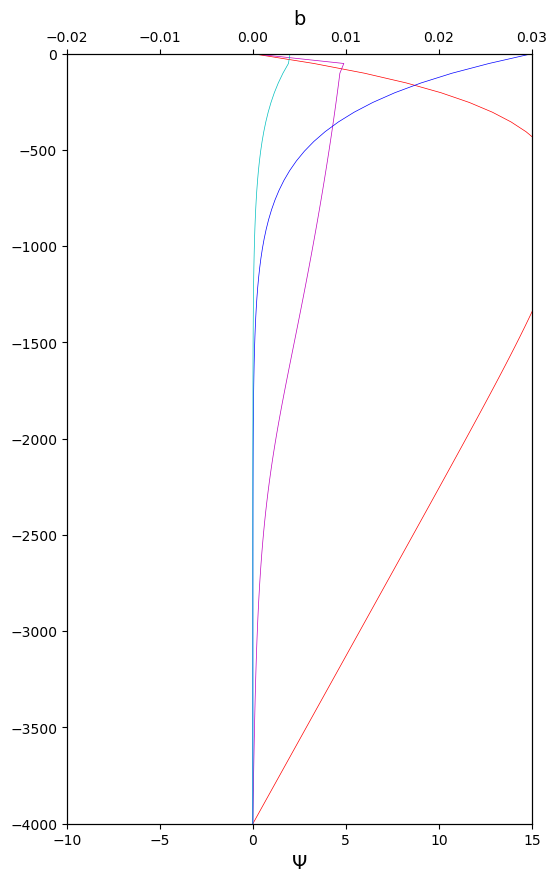

Text(0.5, 1.0, 'Depth-averaged Overturning')

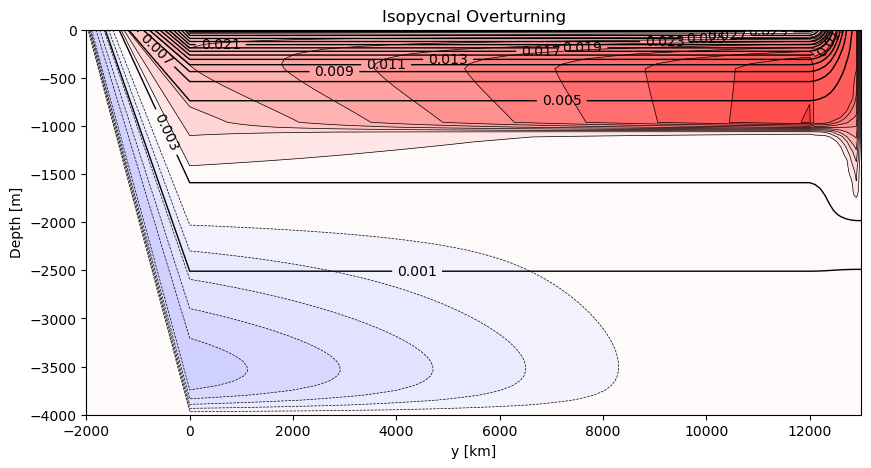

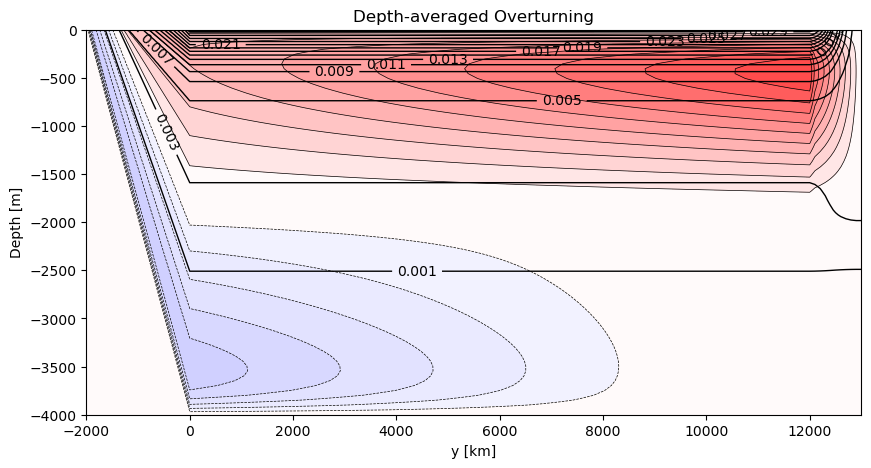

In [11]:
A_basin = 6e13    #area of the basin
A_north = A_basin / 50.    #area of northern sinking region

# time-stepping parameters:
dt = 86400 * 30    # time-step for vert. adv. diff. calc.
MOC_up_iters = int(
    np.floor(2. * 360 * 86400 / dt)
)    # multiplier for MOC time-step (MOC is updated every MOC_up_iters time steps)
plot_iters = int(
    np.ceil(300 * 360 * 86400 / dt)
)    # plotting frequency (in iterations)
total_iters = int(
    np.ceil(3000 * 360 * 86400 / dt)
)    # total number of timesteps

kappa = 2e-5

# create vertical grid:
z = np.asarray(np.linspace(-4000, 0, 80))


# Initial conditions for buoyancy profile in the basin
def b_basin(z):
  return bs * np.exp(z / 300.)
def b_north(z):
  return bs_north * np.exp(z / 300.)


# create N.A. overturning model instance
AMOC = Psi_Thermwind(z=z, b1=b_basin, b2=b_north, f=1e-4)
# and solve for initial overturning streamfunction:
AMOC.solve()
# evaluate overturning in isopycnal space:
[Psi_iso_b, Psi_iso_n] = AMOC.Psibz()

# create S.O. overturning model instance
SO = Psi_SO(
    z=z,
    y=y,
    b=b_basin(z),
    bs=bs_SO,
    tau=tau,
    f=1e-4,
    L=5e6,
    KGM=1000.,
    c=0.1,
    bvp_with_Ek=True
)
SO.solve()

# create adv-diff column model instance for basin
basin = Column(z=z, kappa=kappa, Area=A_basin, b=b_basin, bs=bs, bbot=bmin)
# create adv-diff column model instance for basin
north = Column(z=z, kappa=kappa, Area=A_north, b=b_north, bs=bs_north, bbot=bmin)

# Create figure:
fig = plt.figure(figsize=(6, 10))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()
plt.ylim((-4e3, 0))
ax1.set_xlim((-10, 15))
ax2.set_xlim((-0.02, 0.03))
ax1.set_xlabel('$\Psi$', fontsize=14)
ax2.set_xlabel('b', fontsize=14)

dz = np.diff(z)[0]
dy_SO = y[1] - y[0]        # Southern spacing (channel grid)
dy_N = 1e3                 # Basin–north effective meridional spacing (km → m)

# Main time-stepping loop
for ii in range(total_iters):

    wAb = (Psi_iso_b - SO.Psi) * 1e6
    wAN = -Psi_iso_n * 1e6



    v_SO = -np.gradient(SO.Psi, dz)            # m/s
    vdx_SO_to_basin = v_SO * SO.L              # m²/s transport into basin
    b_in_basin = bs_SO                         # buoyancy coming from SO side

    v_AMOC = -np.gradient(AMOC.Psi, dz)        # m/s
    vdx_basin_to_north = v_AMOC                # AMOC transport already per metre depth
    b_in_north = basin.b.copy()                # buoyancy from basin column



    basin.timestep(
        wA=wAb,
        dt=dt,
        vdx_in=vdx_SO_to_basin,
        b_in=b_in_basin
    )

    north.timestep(
        wA=wAN,
        dt=dt,
        do_conv=True,
        vdx_in=vdx_basin_to_north,
        b_in=b_in_north
    )


    if ii % MOC_up_iters == 0:
        AMOC.update(b1=basin.b, b2=north.b)
        AMOC.solve()
        Psi_iso_b, Psi_iso_n = AMOC.Psibz()
        SO.update(b=basin.b)
        SO.solve()

    if ii % plot_iters == 0:
        ax1.plot(AMOC.Psi, AMOC.z, linewidth=0.5, color='r')
        ax1.plot(SO.Psi, SO.z, linewidth=0.5, color='m')
        ax2.plot(basin.b, basin.z, linewidth=0.5, color='b')
        ax2.plot(north.b, north.z, linewidth=0.5, color='c')
        plt.pause(0.01)


# Plot final results over time-iteration plot:
ax1.plot(AMOC.Psi, AMOC.z, linewidth=2, color='r')
ax1.plot(SO.Psi, SO.z, linewidth=2, color='m')
ax1.plot(SO.Psi_Ek, SO.z, linewidth=1, color='m', linestyle='--')
ax1.plot(SO.Psi_GM, SO.z, linewidth=1, color='m', linestyle=':')
ax2.plot(basin.b, basin.z, linewidth=2, color='b')
ax2.plot(north.b, basin.z, linewidth=2, color='c')
ax1.plot(0. * AMOC.z, AMOC.z, linewidth=0.5, color='k')

#==============================================================================
# Everything below is just to make fancy 2D plots:
# This is mostly an exercise in interpolation, but useful to visualize solutions

# first interpolate buoyancy in channel along constant-slope isopycnals:
bint = Interpolate_channel(y=y, z=z, bs=bs_SO, bn=basin.b)
bsouth = bint.gridit()
# buoyancy in the basin is all the same:
ybasin = np.linspace(200., 12000., 60)
bbasin = np.tile(basin.b, (len(ybasin), 1))
# finally, interpolate buoyancy in the north:
ynorth = np.linspace(12100., 13000., 10)
bnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
  bnorth[:, iz] = interp1d([11900., 12000., 12900., 13000.], [
      basin.b[iz], basin.b[iz], north.b[iz], north.b[iz]
  ],
                           kind='quadratic')(ynorth)
# now stick it all together:
ynew = np.concatenate(((y-l) / 1e3, ybasin, ynorth))
bnew = np.concatenate((bsouth, bbasin, bnorth))

# Evaluate isopycnal overturning streamfunction at all latitudes:
psiarray_iso = np.zeros((len(ynew), len(z)))
psiarray_z = np.zeros((len(ynew), len(z)))
for iy in range(1, len(y)):
  # in the channel, interpolate SO.Psi onto local isopycnal depth:
  psiarray_iso[iy, :] = np.interp(bnew[iy, :], basin.b, SO.Psi)
  psiarray_z[iy, :] = psiarray_iso[iy, :]
for iy in range(len(y), len(y) + len(ybasin)):
  # in the basin, linearly interpolate between Psi_SO and Psi_AMOC:
  psiarray_iso[iy, :] = (
      ynew[iy] * AMOC.Psibz()[0] + (10000. - ynew[iy]) * SO.Psi
  ) / 10000.
  psiarray_z[iy, :
             ] = (ynew[iy] * AMOC.Psi + (10000. - ynew[iy]) * SO.Psi) / 10000.
for iy in range(len(y) + len(ybasin), len(ynew)):
  # in the north, interpolate AMOC.psib to local isopycnal depth:
  psiarray_iso[iy, :] = np.interp(bnew[iy, :], AMOC.bgrid, AMOC.Psib())
  psiarray_z[iy, :] = ((13000. - ynew[iy]) * AMOC.Psi) / 1000.
psiarray_iso[-1, :] = 0.

blevs = np.arange(0.001, 0.03, 0.002)
# Notice that the contour level for Psi is 0.5 SV for negative values
# and 1 SV for positive values. This appers to be what was used in NV2012.
plevs = np.concatenate((np.arange(-15., -0.4, 0.5), np.arange(1., 16., 1.)))

# plot isopycnal overturning:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
CS = ax1.contour(
    ynew,
    z,
    bnew.transpose(),
    levels=blevs,
    colors='k',
    linewidths=1.0,
    linestyles='solid'
)
ax1.clabel(CS, fontsize=10)
ax1.contour(
    ynew,
    z,
    psiarray_iso.transpose(),
    levels=plevs,
    colors='k',
    linewidths=0.5
)
CS = ax1.contourf(
    ynew,
    z,
    psiarray_iso.transpose(),
    levels=plevs,
    cmap=plt.cm.bwr,
    vmin=-15,
    vmax=15
)
#fig.colorbar(CS, ticks=plevs[0::2], orientation='vertical')
ax1.set_xlabel('y [km]')
ax1.set_ylabel('Depth [m]')
ax1.set_title('Isopycnal Overturning')

# plot z-coord. overturning:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
CS = ax1.contour(
    ynew,
    z,
    bnew.transpose(),
    levels=blevs,
    colors='k',
    linewidths=1.0,
    linestyles='solid'
)
ax1.clabel(CS, fontsize=10)
ax1.contour(
    ynew, z, psiarray_z.transpose(), levels=plevs, colors='k', linewidths=0.5
)
CS = ax1.contourf(
    ynew,
    z,
    psiarray_z.transpose(),
    levels=plevs,
    cmap=plt.cm.bwr,
    vmin=-15,
    vmax=15
)
#fig.colorbar(CS, ticks=plevs[0::2], orientation='vertical')
ax1.set_xlabel('y [km]')
ax1.set_ylabel('Depth [m]')
ax1.set_title('Depth-averaged Overturning')

In [12]:
b_in_north.shape

(80,)

In [13]:
bs_SO.shape

(80,)